In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('/home/puru/Documents/House Price Prediction/STEP - 3 (Feature Engg)/STEP - 1/gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,malibu towne,sector 47,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,0.0,West,Moderately Old,NaN,NaN,2400.03,0,0,0,0,0,1,22
1,house,independent,sector 26,10.50,43210.0,2430.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,12,12,3+,4.0,North-East,Relatively New,NaN,2700.02,2429.95,0,1,0,1,0,1,72
2,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,2.0,North-East,Relatively New,1650.00,NaN,1399.95,1,1,0,0,0,1,136
3,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,12.0,North-East,Relatively New,1700.05,NaN,NaN,0,0,0,0,0,0,101
4,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,599.98,NaN,513.98,0,0,0,1,0,0,59


In [6]:
df.shape

(3677, 23)

In [7]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

### `1.` Price

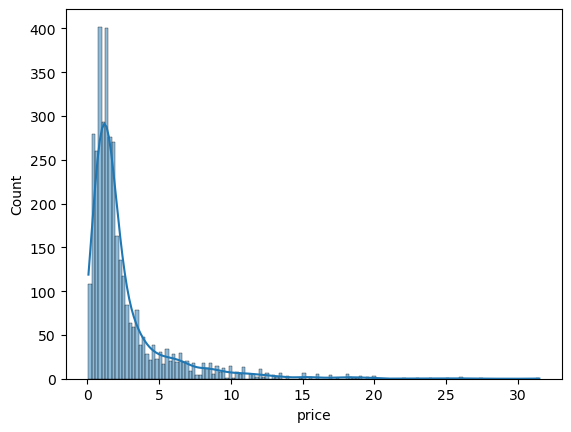

In [8]:
sns.histplot(df['price'],kde=True)
plt.show()

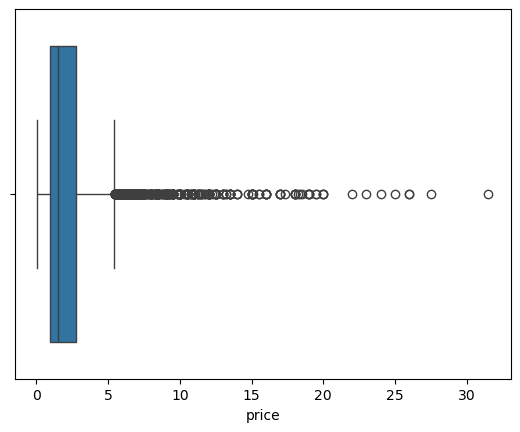

In [9]:
sns.boxplot(x=df['price'])
plt.show()

In [10]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

(lower_bound,upper_bound)

(-1.7500000000000002, 5.45)

In [11]:
# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

print(num_outliers) 
print('*'*30)
print(outliers_price_stats)

425
******************************
count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64


### `2.` Price_per_sqft

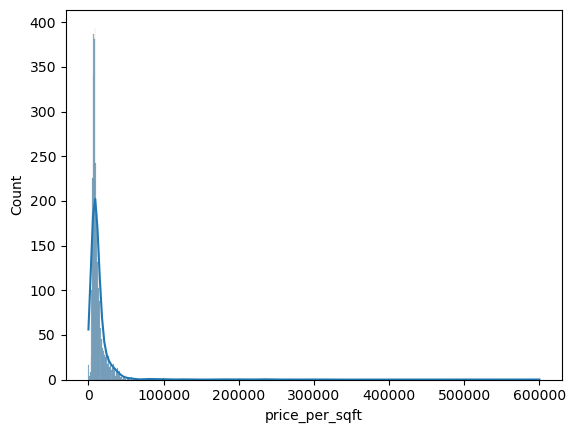

In [12]:
sns.histplot(df['price_per_sqft'],kde=True)
plt.show()

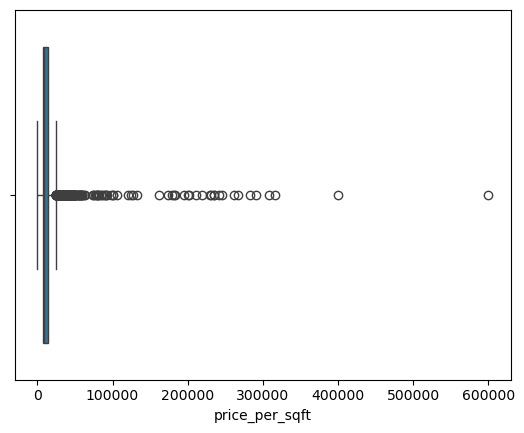

In [13]:
sns.boxplot(x=df['price_per_sqft'])
plt.show()

In [14]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

(lower_bound,upper_bound)

(-3777.625, 24475.375)

In [20]:
# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

print(num_outliers) 
print('*'*30)
print(outliers_sqft_stats)

354
******************************
count       354.000000
mean      52592.612994
std       61150.458507
min       24489.000000
25%       28208.250000
50%       33368.500000
75%       41982.250000
max      600000.000000
Name: price_per_sqft, dtype: float64


In [22]:
outliers_sqft[outliers_sqft['price_per_sqft'] > 60000].shape

(48, 23)

In [27]:
outliers_sqft[outliers_sqft['price_per_sqft']<60000]['price_per_sqft'].describe()

count      305.000000
mean     33829.288525
std       7719.055162
min      24489.000000
25%      27390.000000
50%      32328.000000
75%      38095.000000
max      59259.000000
Name: price_per_sqft, dtype: float64

In [28]:
outlier_indices = outliers_sqft[outliers_sqft['price_per_sqft'] > 60000].index
df = df.drop(outlier_indices)

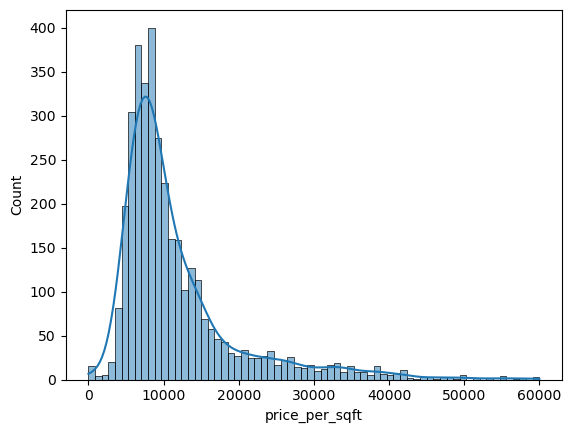

In [29]:
sns.histplot(df['price_per_sqft'],kde=True)
plt.show()

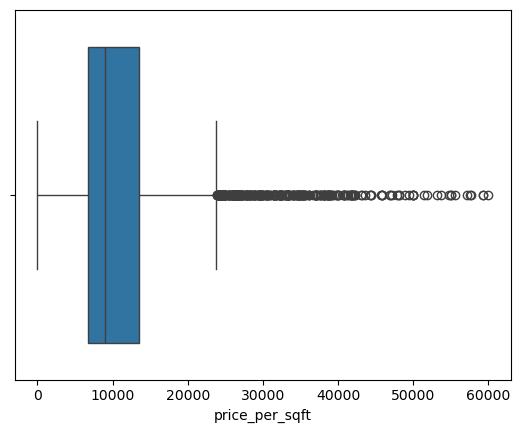

In [30]:
sns.boxplot(x=df['price_per_sqft'])
plt.show()

In [31]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
73,house,nul,sector 28,12.50,51440.0,2430.0,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,NaN,2429.95,NaN,1,1,0,1,1,2,137
717,house,independent,sector 9,1.10,55000.0,200.0,Plot area 200(18.58 sq.m.),4,3,1,2.0,North-East,Old Property,NaN,199.99,NaN,0,0,0,0,0,0,0
847,house,independent,sector 24,3.20,59259.0,540.0,Plot area 60(50.17 sq.m.),14,14,3+,6.0,West,Relatively New,NaN,540.02,NaN,0,0,0,0,0,2,15
1836,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.0,North,Relatively New,NaN,2249.98,1800.05,1,1,1,1,0,1,103
1856,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,NaN,2844.04,NaN,1,1,1,1,0,1,153
2082,house,independent,sector 3 phase 3 extension,0.75,57692.0,130.0,Built Up area: 130 (12.08 sq.m.),2,2,0,1.0,NaN,Undefined,NaN,130.03,NaN,0,0,0,0,0,0,0
2138,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4544.95,NaN,1,1,0,1,1,1,138
2176,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,NaN,2924.98,2700.02,1,1,1,1,0,1,72
2265,flat,unitech vistas,sector 70,9.00,57507.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,NaN,1564.96,NaN,0,0,0,0,0,0,0
2811,house,not applicable,sector 4,0.80,54794.0,146.0,Plot area 146(13.56 sq.m.),5,4,3,3.0,NaN,Under Construction,NaN,145.96,NaN,0,0,0,0,0,0,0


In [32]:
df = df[df['price_per_sqft'] <= 50000]

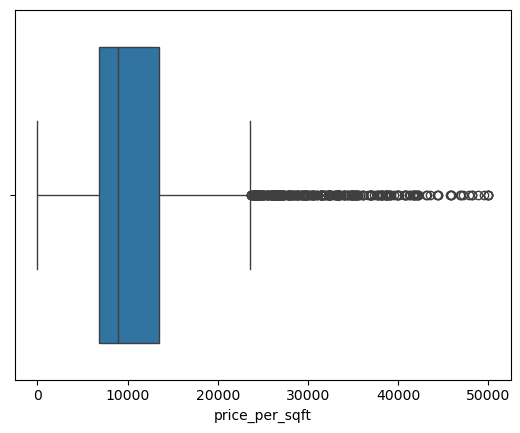

In [33]:
sns.boxplot(x=df['price_per_sqft'])
plt.show()

### `3.` Area

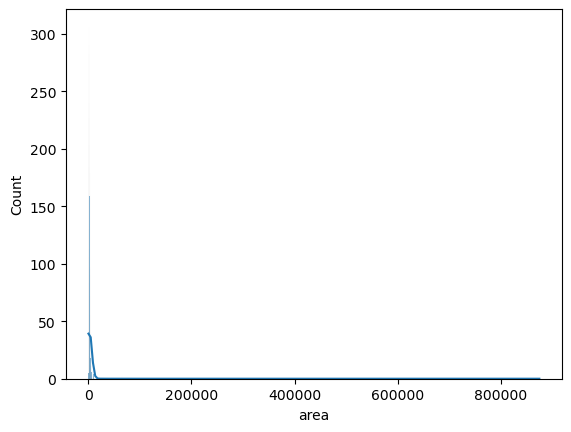

In [34]:
sns.histplot(df['area'],kde=True)
plt.show()

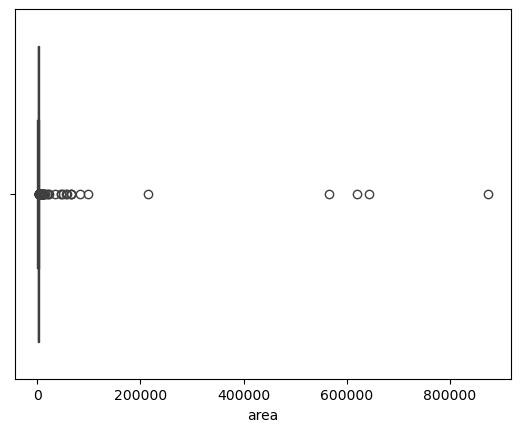

In [35]:
sns.boxplot(x=df['area'])
plt.show()

In [36]:
df['area'].describe()

count      3598.000000
mean       2926.910784
std       23364.099225
min          72.000000
25%        1251.250000
50%        1743.500000
75%        2308.750000
max      875000.000000
Name: area, dtype: float64

In [37]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
63,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,10889.95,NaN,1,1,0,1,1,1,0
1119,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607935.38,1,0,0,0,1,0,65
1493,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514395.48,0,0,0,0,0,0,44
2030,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569242.50,0,0,0,0,0,0,76
3180,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737146.32,NaN,0,0,0,0,0,2,44


In [38]:
df = df[df['area'] < 100000]

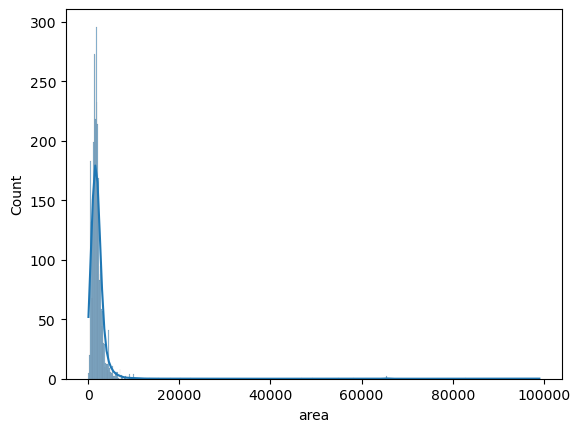

In [39]:
sns.histplot(df['area'],kde=True)
plt.show()

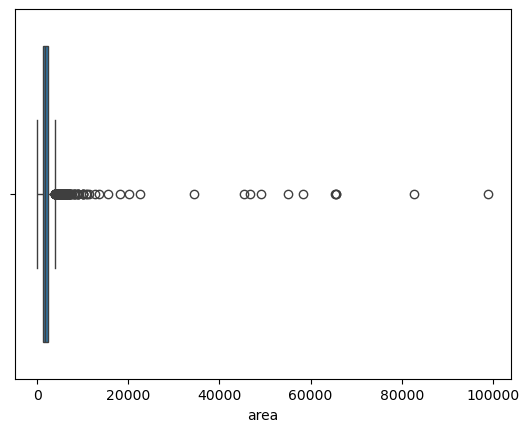

In [40]:
sns.boxplot(x=df['area'])
plt.show()

In [41]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1648,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,98999.89,0,1,1,1,0,1,60
1806,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,82805.18,NaN,0,0,0,0,1,0,7
1883,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64528.93,1,0,0,0,0,0,15
862,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64411.93,0,0,0,0,0,0,51
1410,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,65249.90,0,0,0,0,0,0,0
1768,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58140.99,0,0,0,0,0,0,15
1420,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54916.99,0,0,0,0,0,0,37
2580,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48810.95,1,0,0,0,0,0,37
173,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,52199.96,46799.93,0,1,1,0,0,1,109
1079,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45965.94,0,0,0,0,1,0,33


In [42]:
df.drop(index=[2346,2900,3603,2998,2838,1877,226,17,1563,1235,1079,173,2580,1420,1768,1410,862,1883,1806,1648], inplace=True)

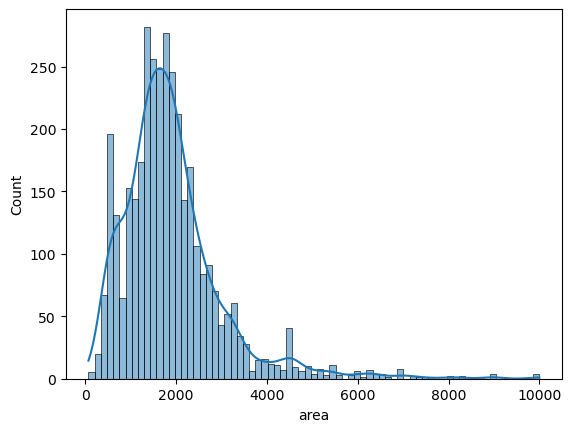

In [43]:
sns.histplot(df['area'],kde=True)
plt.show()

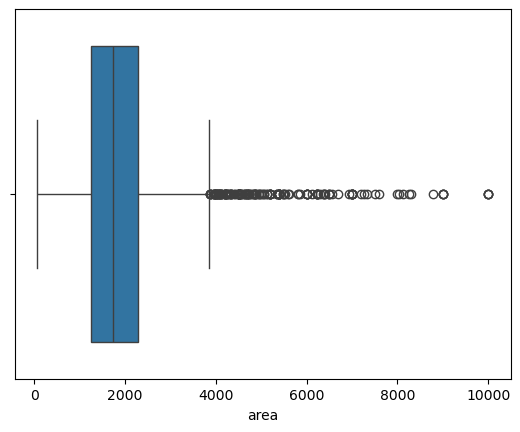

In [44]:
sns.boxplot(x=df['area'])
plt.show()

In [45]:
df['area'].describe()

count     3573.000000
mean      1905.540722
std       1134.317941
min         72.000000
25%       1250.000000
50%       1738.000000
75%       2295.000000
max      10000.000000
Name: area, dtype: float64

### `4.` Bedroom

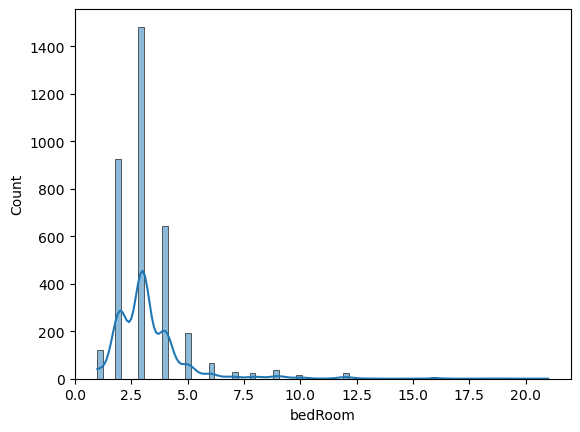

In [46]:
sns.histplot(df['bedRoom'],kde=True)
plt.show()

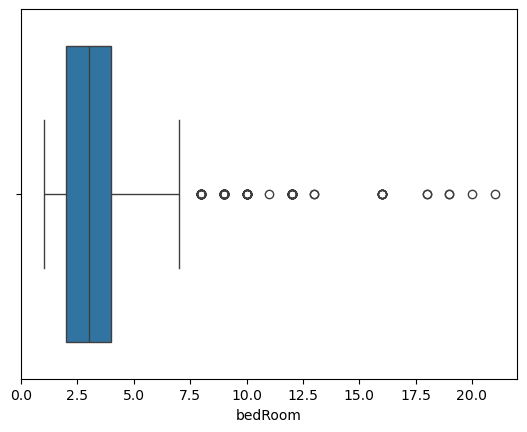

In [47]:
sns.boxplot(x=df['bedRoom'])
plt.show()

In [48]:
df['bedRoom'].describe()

count    3573.000000
mean        3.290512
std         1.759986
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [49]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
831,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1160.99,NaN,0,1,0,0,0,2,49
3003,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1151.95,NaN,0,1,0,0,0,2,22
1671,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7499.96,NaN,1,0,1,0,0,0,68
1920,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.01,NaN,1,1,1,1,0,0,74
1546,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1439.99,NaN,0,1,0,0,0,2,70
2320,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1502.96,NaN,0,0,0,0,1,2,57
1831,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.04,NaN,1,1,1,1,0,1,153
83,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16,18,3+,4.0,North-East,New Property,NaN,2700.02,NaN,0,1,0,1,0,1,49
868,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,4499.96,NaN,0,1,0,0,0,1,31
715,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,NaN,2700.02,NaN,0,1,0,1,0,1,49


In [50]:
df = df[df['bedRoom'] <= 10]

In [51]:
df.shape

(3535, 23)

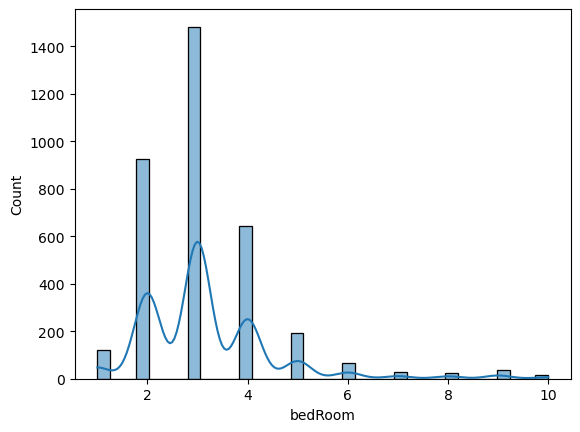

In [52]:
sns.histplot(df['bedRoom'],kde=True)
plt.show()

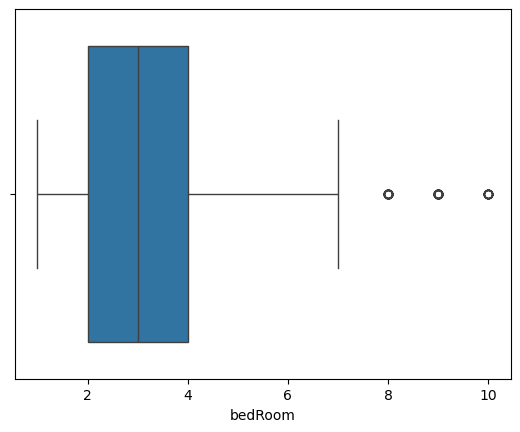

In [53]:
sns.boxplot(x=df['bedRoom'])
plt.show()

In [54]:
df['bedRoom'].describe()

count    3535.000000
mean        3.176521
std         1.351167
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

### `5.` Bathroom

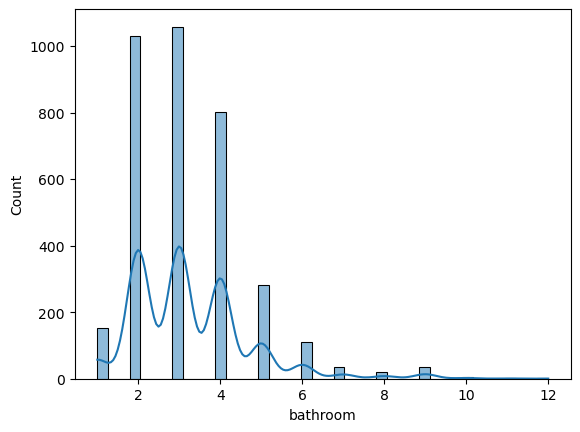

In [55]:
sns.histplot(df['bathroom'],kde=True)
plt.show()

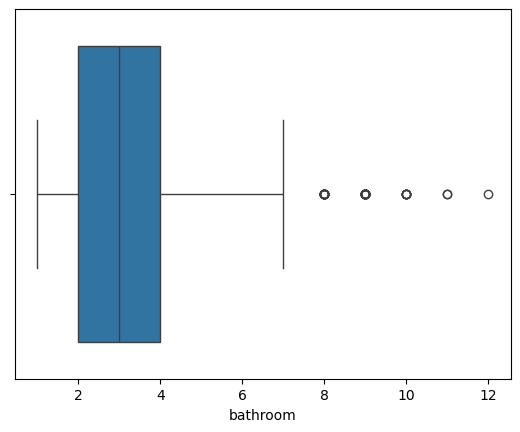

In [56]:
sns.boxplot(x=df['bathroom'])
plt.show()

In [57]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1087,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6389.99,NaN,0,1,0,0,0,1,146
712,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,6999.98,NaN,0,0,0,1,0,1,38
2093,house,independent,sector 24,11.00,28898.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.05,NaN,1,1,0,1,1,1,39


In [58]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,malibu towne,sector 47,2.40,10000.0,2400.0,Carpet area: 2400 (222.97 sq.m.),3,3,0,0.0,West,Moderately Old,NaN,NaN,2400.03,0,0,0,0,0,1,22
2,flat,emaar mgf emerald floors premier,sector 65,2.36,14303.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,2.0,North-East,Relatively New,1650.00,NaN,1399.95,1,1,0,0,0,1,136
3,flat,puri diplomatic greens,sector 111,2.25,13235.0,1700.0,Super Built up area 1700(157.94 sq.m.),3,3,2,12.0,North-East,Relatively New,1700.05,NaN,NaN,0,0,0,0,0,0,101
4,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,5.0,South-West,Relatively New,599.98,NaN,513.98,0,0,0,1,0,0,59
5,flat,bestech park view residency,sector 2,1.40,7865.0,1780.0,Super Built up area 1780(165.37 sq.m.),3,3,3+,8.0,South-West,Moderately Old,1780.03,NaN,NaN,0,0,0,0,0,0,92


### `6.` super built up area

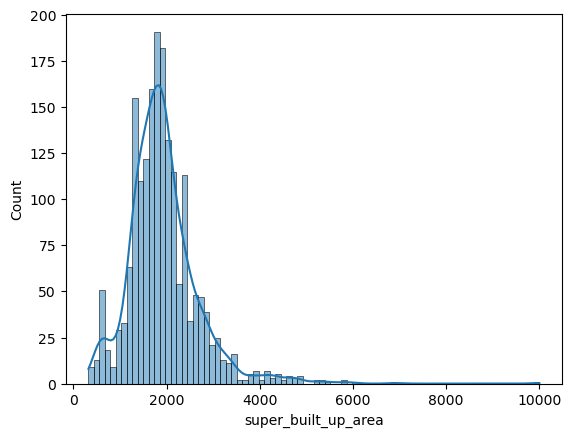

In [59]:
sns.histplot(df['super_built_up_area'],kde=True)
plt.show()

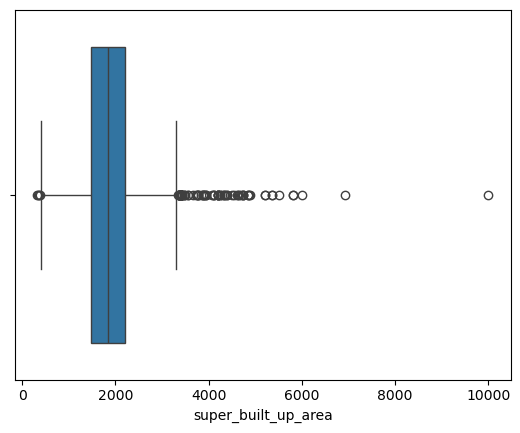

In [60]:
sns.boxplot(x=df['super_built_up_area'])
plt.show()

In [61]:
df['super_built_up_area'].describe()

count    1869.000000
mean     1930.307566
std       759.626682
min       324.960000
25%      1481.010000
50%      1832.020000
75%      2215.000000
max      9999.990000
Name: super_built_up_area, dtype: float64

In [62]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
491,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,9999.99,NaN,NaN,0,1,0,1,1,0,49
1219,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.03,NaN,NaN,0,1,0,0,0,1,140
1245,flat,.,gwal pahari,7.0,11000.0,6364.0,Super Built up area 6000(557.42 sq.m.),4,4,3+,6.0,South-West,Relatively New,6000.01,NaN,NaN,0,1,0,0,0,0,52


### `7.` built up area

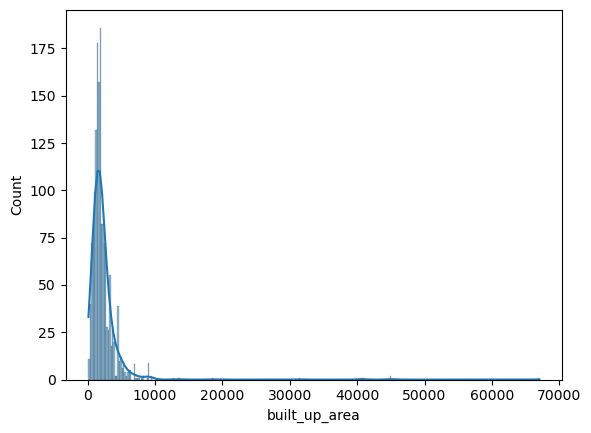

In [63]:
sns.histplot(df['built_up_area'],kde=True)
plt.show()

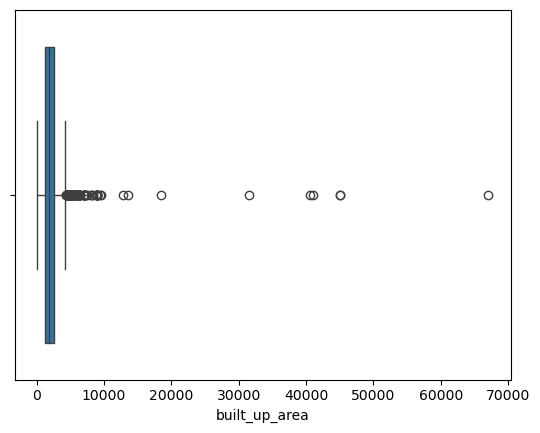

In [64]:
sns.boxplot(x=df['built_up_area'])
plt.show()

In [65]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
176,house,independent,sector 23,5.65,17706.0,3191.0,Plot area 342(285.96 sq.m.)Built Up area: 5000...,7,7,3+,2.0,West,Moderately Old,NaN,44999.99,35999.97,0,1,0,1,0,0,68
409,house,ansal api spanish court,sector 2,2.90,18626.0,1557.0,Plot area 173(144.65 sq.m.)Built Up area: 1415...,4,4,3,2.0,North,Relatively New,NaN,12734.99,12149.97,0,0,1,0,0,1,49
478,house,unitech espace,sector 50,7.45,34491.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 4500...,4,4,3,3.0,NaN,Old Property,NaN,40499.93,35999.97,0,1,0,0,0,1,59
1535,house,kothi,sector 17b,6.95,15444.0,4500.0,Plot area 500(418.06 sq.m.)Built Up area: 3500...,4,4,3+,2.0,NaN,Old Property,NaN,31500.02,NaN,1,1,1,1,0,0,33
2038,house,independent,sector 12,1.35,12222.0,1105.0,Plot area 150(125.42 sq.m.)Built Up area: 2052...,5,5,1,3.0,NaN,Old Property,NaN,18467.95,NaN,0,0,0,0,0,0,31
2930,house,experion windchants,sector 112,9.50,23457.0,4050.0,Plot area 450(376.26 sq.m.)Built Up area: 7450...,5,5,3,2.0,NaN,Relatively New,NaN,67049.95,NaN,0,1,0,0,0,0,45
3073,house,ansal heights,sector 92,2.75,9793.0,2808.0,Plot area 312(260.87 sq.m.)Built Up area: 5000...,4,4,3+,3.0,NaN,Relatively New,NaN,44999.99,NaN,1,0,0,1,0,0,0
3540,house,independent,sector 23,1.20,6230.0,1926.0,Plot area 214(178.93 sq.m.)Built Up area: 1500...,3,2,2,3.0,NaN,New Property,NaN,13499.98,NaN,0,0,0,0,0,1,79
3552,house,ansals palam vihar,sector 2,5.70,14729.0,3870.0,Plot area 430(359.53 sq.m.)Built Up area: 4550...,5,5,2,2.0,North-East,Old Property,NaN,40949.97,40050.00,0,0,0,1,0,2,94


### `8.` carpet area

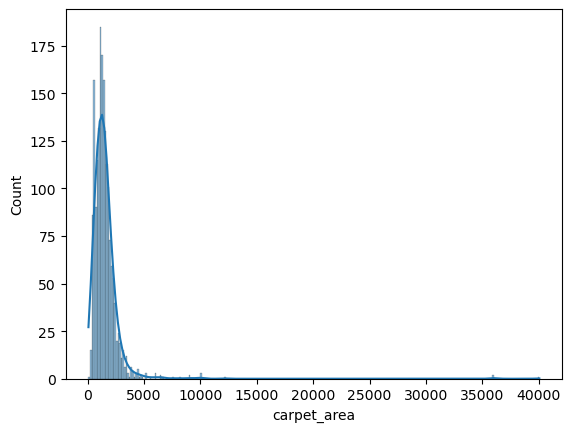

In [66]:
sns.histplot(df['carpet_area'],kde=True)
plt.show()

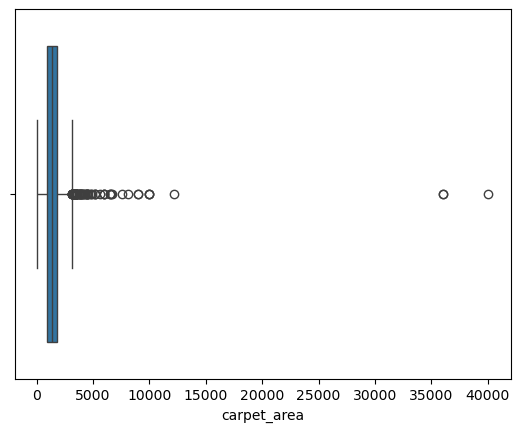

In [67]:
sns.boxplot(x=df['carpet_area'])
plt.show()

In [68]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
176,house,independent,sector 23,5.65,17706.0,3191.0,Plot area 342(285.96 sq.m.)Built Up area: 5000...,7,7,3+,2.0,West,Moderately Old,NaN,44999.99,35999.97,0,1,0,1,0,0,68
409,house,ansal api spanish court,sector 2,2.90,18626.0,1557.0,Plot area 173(144.65 sq.m.)Built Up area: 1415...,4,4,3,2.0,North,Relatively New,NaN,12734.99,12149.97,0,0,1,0,0,1,49
478,house,unitech espace,sector 50,7.45,34491.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 4500...,4,4,3,3.0,NaN,Old Property,NaN,40499.93,35999.97,0,1,0,0,0,1,59
3552,house,ansals palam vihar,sector 2,5.70,14729.0,3870.0,Plot area 430(359.53 sq.m.)Built Up area: 4550...,5,5,2,2.0,North-East,Old Property,NaN,40949.97,40050.00,0,0,0,1,0,2,94


### `9.` Luxury Score

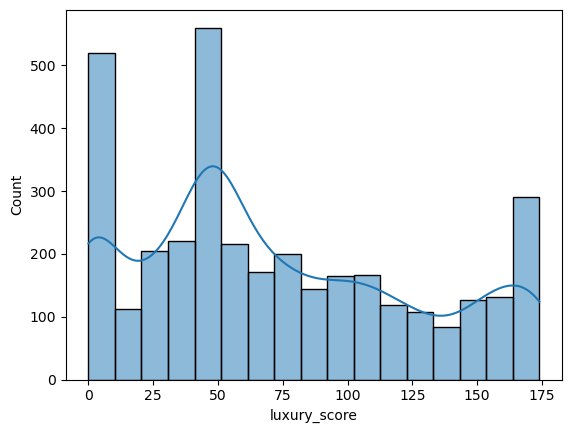

In [69]:
sns.histplot(df['luxury_score'],kde=True)
plt.show()

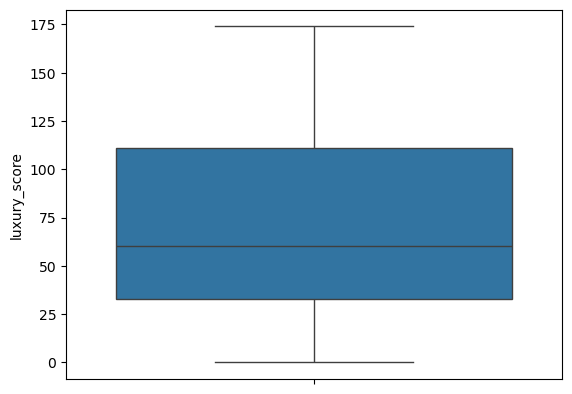

In [70]:
sns.boxplot(df['luxury_score'])
plt.show()

In [71]:
df.shape

(3535, 23)

In [72]:
df.to_csv('gurgaon_properties_outlier_treated.csv',index=False)